In [1]:
### Cell 1: Imports ###
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [14]:
### Cell 2: Load and Preprocess Data ###
# UPDATED FOR 3D: Added 'z' to input and 'Uz' to output
df = pd.read_csv('/kaggle/input/experiment2-pinns/4_Blocks_3D.csv')
df_subset = df.groupby('time', group_keys=False).head(75)
df_2 = df.groupby('time', group_keys=False).head(10000)
print(f"Original shape: {df.shape}")
print(f"Subset shape: {df_subset.shape}")

# Optional — check how many unique time steps and how many samples per step
print(f"Unique time steps: {df_subset['time'].nunique()}")
print(df_subset['time'].value_counts().head())

X = df_subset[['time', 'x', 'y', 'z']].values
Y = df_subset[['Ux', 'Uy', 'Uz', 'p']].values

X_all = df_2[['time', 'x', 'y', 'z']].values
Y_all = df_2[['Ux', 'Uy', 'Uz', 'p']].values

y_scaler = StandardScaler()
Y_scaled = y_scaler.fit_transform(Y)
Y_scaled_all = y_scaler.transform(Y_all)

x_train_tensor = torch.tensor(X, dtype=torch.float32)
x_all_tensor = torch.tensor(X_all, dtype=torch.float32)
y_train_tensor = torch.tensor(Y_scaled, dtype=torch.float32)
y_all_tensor = torch.tensor(Y_scaled_all,dtype=torch.float32)

print(f"Input shape: {x_train_tensor.shape}")
print(f"Output shape: {y_train_tensor.shape}")

print(f"Input shape: {x_all_tensor.shape}")
print(f"Output shape: {y_all_tensor.shape}")

Original shape: (6528000, 9)
Subset shape: (3825, 9)
Unique time steps: 51
time
0.0    75
0.1    75
0.2    75
0.3    75
0.4    75
Name: count, dtype: int64
Input shape: torch.Size([3825, 4])
Output shape: torch.Size([3825, 4])
Input shape: torch.Size([510000, 4])
Output shape: torch.Size([510000, 4])


In [3]:
class ANN3D(nn.Module):
    def __init__(self, input_dim=4, output_dim=4, hidden_dim=128, num_layers=4):
        """
        A simple fully-connected ANN for regression (no PDE loss).
        Good baseline to compare against PINNs.
        """
        super(ANN3D, self).__init__()
        
        layers = []
        layers.append(nn.Linear(input_dim, hidden_dim))
        
        # Use fewer hidden layers
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
        
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.layers = nn.ModuleList(layers)
        
        # Activation function — ReLU often converges faster for pure ANNs
        self.activation = F.relu  
        
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.layers:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                if layer.bias is not None:
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        # Simple forward pass
        for layer in self.layers[:-1]:
            x = self.activation(layer(x))
        return self.layers[-1](x)

In [4]:
### Cell 7: Training Loop (ANN + Early Stopping + AMP) ###
def train_ann(model, optimizer, iterations, x_train, y_train, val_x, val_y):
    logs = {"iteration": [], "train_loss": [], "val_loss": []}
    best_val_loss = float('inf')
    patience = 500
    patience_counter = 0

    for iteration in range(1, iterations + 1):
        model.train()
        optimizer.zero_grad()

        
        pred = model(x_train)
        loss = F.mse_loss(pred, y_train)

        loss.backward()
        optimizer.step()

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(val_x)
            val_loss = F.mse_loss(val_pred, val_y)

        # Logging
        logs["iteration"].append(iteration)
        logs["train_loss"].append(loss.item())
        logs["val_loss"].append(val_loss.item())

        if iteration % 100 == 0:
            print(f"Iter {iteration}: Train Loss = {loss.item():.4e}, Val Loss = {val_loss.item():.4e}")

        # Early stopping
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            torch.save(model.state_dict(), "best_ann_model.pth")
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at iteration {iteration}")
            break

    # Load best model
    model.load_state_dict(torch.load("best_ann_model.pth"))
    return logs

In [5]:
import matplotlib.pyplot as plt

def plot_training_logs(logs, title="ANN Training Progress"):
    """
    Plots training and validation loss curves from the logs dictionary.
    Args:
        logs: dict with keys ['iteration', 'train_loss', 'val_loss']
        title: plot title
    """
    plt.figure(figsize=(8, 5))
    plt.plot(logs["iteration"], logs["train_loss"], label="Train Loss", linewidth=2)
    plt.plot(logs["iteration"], logs["val_loss"], label="Validation Loss", linewidth=2)
    plt.xlabel("Iteration", fontsize=12)
    plt.ylabel("MSE Loss", fontsize=12)
    plt.title(title, fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [6]:
### Cell 8: Setup Training ###
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

torch.manual_seed(42)
indices = torch.randperm(x_train_tensor.size(0))
train_size = int(0.8 * x_train_tensor.size(0))

x_train = x_train_tensor[indices[:train_size]].to(device)
y_train = y_train_tensor[indices[:train_size]].to(device)
x_val = x_train_tensor[indices[train_size:]].to(device)
y_val = y_train_tensor[indices[train_size:]].to(device)

model = ANN3D(input_dim=4, output_dim=4, hidden_dim=256, num_layers=8).to(device)

Using device: cuda


In [7]:
### Cell 9: Train the ANN ###
lr = 0.001
iterations = 3000
optimizer_adam = optim.Adam(model.parameters(), lr=lr)

logs_ann = train_ann(model, optimizer_adam, iterations, x_train, y_train, x_val, y_val)

Iter 100: Train Loss = 8.3807e-02, Val Loss = 7.1859e-02
Iter 200: Train Loss = 6.0321e-02, Val Loss = 5.9837e-02
Iter 300: Train Loss = 5.0411e-02, Val Loss = 2.9901e-02
Iter 400: Train Loss = 2.0312e-02, Val Loss = 2.0420e-02
Iter 500: Train Loss = 1.2289e-01, Val Loss = 4.3916e-02
Iter 600: Train Loss = 1.1077e-02, Val Loss = 1.6441e-02
Iter 700: Train Loss = 4.7634e-03, Val Loss = 7.8793e-03
Iter 800: Train Loss = 5.2560e-03, Val Loss = 5.0175e-03
Iter 900: Train Loss = 5.2119e-03, Val Loss = 7.5410e-03
Iter 1000: Train Loss = 2.3586e-03, Val Loss = 2.6588e-03
Iter 1100: Train Loss = 8.8685e-03, Val Loss = 5.8029e-03
Iter 1200: Train Loss = 2.5581e-03, Val Loss = 1.9376e-03
Iter 1300: Train Loss = 5.6318e-03, Val Loss = 3.2449e-03
Iter 1400: Train Loss = 3.6003e-03, Val Loss = 5.7874e-03
Iter 1500: Train Loss = 1.6868e-03, Val Loss = 1.6596e-03
Iter 1600: Train Loss = 6.4552e-03, Val Loss = 2.7152e-03
Iter 1700: Train Loss = 1.5528e-02, Val Loss = 9.5296e-03
Iter 1800: Train Loss =

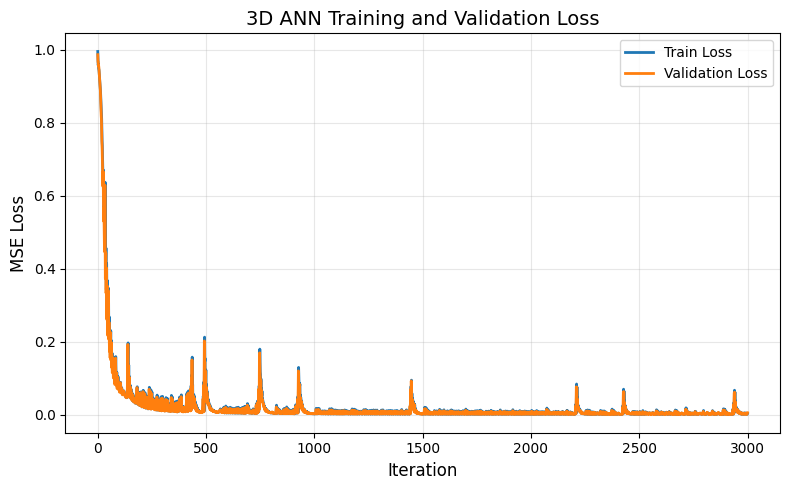

In [8]:
plot_training_logs(logs_ann, title="3D ANN Training and Validation Loss")

In [15]:
### Cell 15: Calculate L2 Error on Training Data ###
model.eval()
with torch.no_grad():
    # Predict on the full dataset
    x_all_tensor = torch.tensor(X_all, dtype=torch.float32).to(device)
    y_pred_scaled = model(x_all_tensor)

# Convert predictions and ground truth back to original scale
y_pred_orig = y_scaler.inverse_transform(y_pred_scaled.cpu().numpy())
y_true_orig = y_scaler.inverse_transform(y_all_tensor.cpu().numpy())



# ---- Compute metrics per component ----
mae = np.mean(np.abs(y_pred_orig - y_true_orig), axis=0)
mse = np.mean((y_pred_orig - y_true_orig) ** 2, axis=0)
l2 = np.linalg.norm(y_pred_orig - y_true_orig, axis=0) / np.linalg.norm(y_true_orig, axis=0)





# ---- Print results ----
components = ['U_x', 'U_y', 'U_z', 'p']
print("\n=== Full-Dataset Evaluation ===")
for i, comp in enumerate(components):
    print(f"{comp}: MAE = {mae[i]:.4f}, MSE = {mse[i]:.4f}, L2 = {l2[i]:.4f}")





# ---- Optional: Velocity magnitude evaluation ----
vel_pred = np.sqrt(np.sum(y_pred_orig[:, :3] ** 2, axis=1))
vel_true = np.sqrt(np.sum(y_true_orig[:, :3] ** 2, axis=1))

mae_vel = np.mean(np.abs(vel_pred - vel_true))
mse_vel = np.mean((vel_pred - vel_true) ** 2)
l2_vel = np.linalg.norm(vel_pred - vel_true) / np.linalg.norm(vel_true)

print(f"\nVelocity Magnitude: MAE = {mae_vel:.4f}, MSE = {mse_vel:.4f}, L2 = {l2_vel:.4f}")


=== Full-Dataset Evaluation ===
U_x: MAE = 0.0277, MSE = 0.0010, L2 = 0.6266
U_y: MAE = 0.0001, MSE = 0.0000, L2 = 1.2572
U_z: MAE = 0.0000, MSE = 0.0000, L2 = 0.6866
p: MAE = 0.0001, MSE = 0.0000, L2 = 0.1538

Velocity Magnitude: MAE = 0.0277, MSE = 0.0010, L2 = 0.6267
